In [7]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize

# NLTK kütüphanesini hazırla
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# 1. Dosyayı oku
# Dosyayı satır satır oku ve 'document_id', 'content' yapısını kendin oluştur
data = []
with open('ham_veri.csv', 'r', encoding='latin1') as f:
    for i, line in enumerate(f):
        if i == 0: continue # Başlığı atla
        data.append([i, line.strip()])

df = pd.DataFrame(data, columns=['document_id', 'content'])
print(df.head())
# 2. Temizleme fonksiyonu
def clean_text(text, mode='lemma'):
    text = str(text).lower() # Küçük harfe çevir
    text = re.sub(r'[^a-zçğıöşü\s]', '', text) # Özel karakterleri temizle
    tokens = word_tokenize(text) # Tokenlere ayır
    
    # Türkçe stop-words temizliği
    stop_words = set(stopwords.words('turkish'))
    tokens = [t for t in tokens if t not in stop_words]
    
    if mode == 'stem':
        stemmer = PorterStemmer()
        return " ".join([stemmer.stem(t) for t in tokens])
    else:
        lemmatizer = WordNetLemmatizer()
        return " ".join([lemmatizer.lemmatize(t) for t in tokens])

# 3. İki farklı veri setini oluştur
df['stemmed_content'] = df['content'].apply(lambda x: clean_text(x, mode='stem'))
df['lemmatized_content'] = df['content'].apply(lambda x: clean_text(x, mode='lemma'))

# 4. Dosyaları kaydet
df[['document_id', 'stemmed_content']].to_csv('stemmed.csv', index=False)
df[['document_id', 'lemmatized_content']].to_csv('lemmatized.csv', index=False)

print("İşlem tamamlandı! stemmed.csv ve lemmatized.csv dosyaları oluşturuldu.")
print(df[['content', 'stemmed_content', 'lemmatized_content']].head())

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


   document_id                                            content
0            1  "Dýþiþleri Bakaný Davutoðlu, Yunanistan ile Tü...
1            2                    ";dünya;"'Ortak vizyonumuz var'
2            3                                                  "
3            4  "Ýsrail Gazze Þeridi'nin kuzeyindeki bir tarla...
4            5  ";dünya;"Ýsrail'den Gazze Þeridi'ne hava saldý...
İşlem tamamlandı! stemmed.csv ve lemmatized.csv dosyaları oluşturuldu.
                                             content  \
0  "Dýþiþleri Bakaný Davutoðlu, Yunanistan ile Tü...   
1                    ";dünya;"'Ortak vizyonumuz var'   
2                                                  "   
3  "Ýsrail Gazze Þeridi'nin kuzeyindeki bir tarla...   
4  ";dünya;"Ýsrail'den Gazze Þeridi'ne hava saldý...   

                                     stemmed_content  \
0  dileri bakan davutolu yunanistan türkiy arasnd...   
1                          dünyaortak vizyonumuz var   
2                           

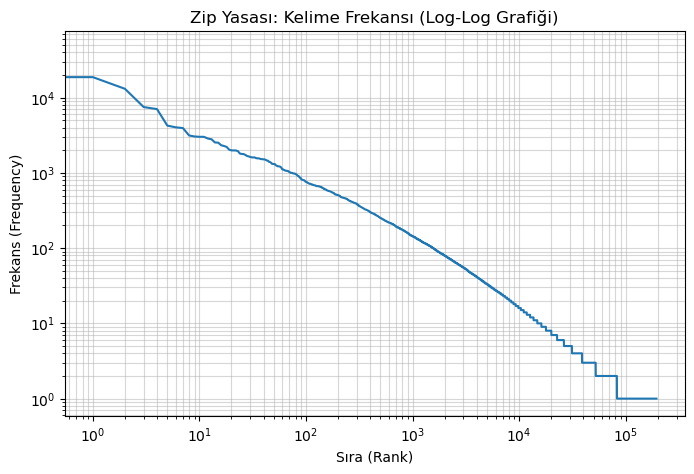

In [8]:
import matplotlib.pyplot as plt
from collections import Counter

# Ham verideki tüm kelimeleri birleştirip sayıyoruz
all_words = " ".join(df['content'].astype(str)).split()
word_counts = Counter(all_words)

# Frekansları büyükten küçüğe sırala
freqs = sorted(word_counts.values(), reverse=True)

# Log-log grafiğini çiz
plt.figure(figsize=(8, 5))
plt.loglog(freqs)
plt.title("Zip Yasası: Kelime Frekansı (Log-Log Grafiği)")
plt.xlabel("Sıra (Rank)")
plt.ylabel("Frekans (Frequency)")
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

In [11]:
!pip install gensim

In [12]:
from gensim.models import Word2Vec
import os

# Modellerin kaydedileceği klasörü oluştur
if not os.path.exists('models'):
    os.makedirs('models')

# Parametre kombinasyonları
parameters = [
    {'model_type': 'cbow', 'window': 2, 'vector_size': 100},
    {'model_type': 'cbow', 'window': 2, 'vector_size': 300},
    {'model_type': 'cbow', 'window': 4, 'vector_size': 100},
    {'model_type': 'cbow', 'window': 4, 'vector_size': 300},
    {'model_type': 'skipgram', 'window': 2, 'vector_size': 100},
    {'model_type': 'skipgram', 'window': 2, 'vector_size': 300},
    {'model_type': 'skipgram', 'window': 4, 'vector_size': 100},
    {'model_type': 'skipgram', 'window': 4, 'vector_size': 300}
]

datasets = {'stemmed': 'stemmed.csv', 'lemmatized': 'lemmatized.csv'}

# 16 Modelin eğitimi
for data_name, file_path in datasets.items():
    df = pd.read_csv(file_path)
    # Metinleri liste haline getir (her doküman bir cümle listesidir)
    sentences = [str(row).split() for row in df.iloc[:, 1].fillna('')]
    
    for p in parameters:
        sg = 1 if p['model_type'] == 'skipgram' else 0
        model = Word2Vec(sentences, vector_size=p['vector_size'], window=p['window'], sg=sg, min_count=1)
        
        # İsimlendirme: word2vec_stemmed_cbow_win2_dim100.model gibi
        file_name = f"models/word2vec_{data_name}_{p['model_type']}_win{p['window']}_dim{p['vector_size']}.model"
        model.save(file_name)
        print(f"Eğitildi: {file_name}")

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Eğitildi: models/word2vec_stemmed_cbow_win2_dim100.model


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Eğitildi: models/word2vec_stemmed_cbow_win2_dim300.model


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


...

Eğitildi: models/word2vec_lemmatized_skipgram_win2_dim300.model


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Eğitildi: models/word2vec_lemmatized_skipgram_win4_dim100.model


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Eğitildi: models/word2vec_lemmatized_skipgram_win4_dim300.model


In [14]:
import pandas as pd
import numpy as np
import os
from gensim.models import Word2Vec

# Vektörleştirme fonksiyonu: Cümledeki kelimelerin ortalamasını alır
def get_sentence_vector(model, sentence):
    words = str(sentence).split()
    word_vectors = [model.wv[word] for word in words if word in model.wv]
    if len(word_vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(word_vectors, axis=0)

In [15]:
from sklearn.metrics.pairwise import cosine_similarity

# Örnek giriş metni (Veri setindeki ilk satır)
df_sample = pd.read_csv('lemmatized.csv') # veya stemmed.csv
query_text = str(df_sample.iloc[0, 1]) 
all_sentences = df_sample.iloc[:100, 1].values # Hız için ilk 100 satır

model_files = [f for f in os.listdir('models') if f.endswith('.model')]
results = {}

for m_file in model_files:
    model = Word2Vec.load(f"models/{m_file}")
    query_vec = get_sentence_vector(model, query_text).reshape(1, -1)
    doc_vecs = np.array([get_sentence_vector(model, s) for s in all_sentences])
    
    similarities = cosine_similarity(query_vec, doc_vecs).flatten()
    top_5_idx = similarities.argsort()[-5:][::-1]
    
    results[m_file] = set(top_5_idx)
    print(f"Model {m_file} için en iyi 5 indeks: {top_5_idx}")

Model word2vec_lemmatized_cbow_win2_dim100.model için en iyi 5 indeks: [ 0 21 39 84 18]
Model word2vec_lemmatized_cbow_win2_dim300.model için en iyi 5 indeks: [ 0 21 84 39 18]
Model word2vec_lemmatized_cbow_win4_dim100.model için en iyi 5 indeks: [ 0 21 84 39 75]
Model word2vec_lemmatized_cbow_win4_dim300.model için en iyi 5 indeks: [ 0 21 84 75 39]
Model word2vec_lemmatized_skipgram_win2_dim100.model için en iyi 5 indeks: [ 0 21 39 84 51]
Model word2vec_lemmatized_skipgram_win2_dim300.model için en iyi 5 indeks: [ 0 21 84 39 51]
Model word2vec_lemmatized_skipgram_win4_dim100.model için en iyi 5 indeks: [ 0 21 84 90 39]
Model word2vec_lemmatized_skipgram_win4_dim300.model için en iyi 5 indeks: [ 0 21 84 90 60]
Model word2vec_stemmed_cbow_win2_dim100.model için en iyi 5 indeks: [ 0 21 39 84 18]
Model word2vec_stemmed_cbow_win2_dim300.model için en iyi 5 indeks: [ 0 21 39 18 84]
Model word2vec_stemmed_cbow_win4_dim100.model için en iyi 5 indeks: [ 0 21 84 39 75]
Model word2vec_stemmed_cb

                                                word2vec_lemmatized_cbow_win2_dim100.model  \
word2vec_lemmatized_cbow_win2_dim100.model                                        1.000000   
word2vec_lemmatized_cbow_win2_dim300.model                                        1.000000   
word2vec_lemmatized_cbow_win4_dim100.model                                        0.666667   
word2vec_lemmatized_cbow_win4_dim300.model                                        0.666667   
word2vec_lemmatized_skipgram_win2_dim100.model                                    0.666667   
word2vec_lemmatized_skipgram_win2_dim300.model                                    0.666667   
word2vec_lemmatized_skipgram_win4_dim100.model                                    0.666667   
word2vec_lemmatized_skipgram_win4_dim300.model                                    0.428571   
word2vec_stemmed_cbow_win2_dim100.model                                           1.000000   
word2vec_stemmed_cbow_win2_dim300.model                     

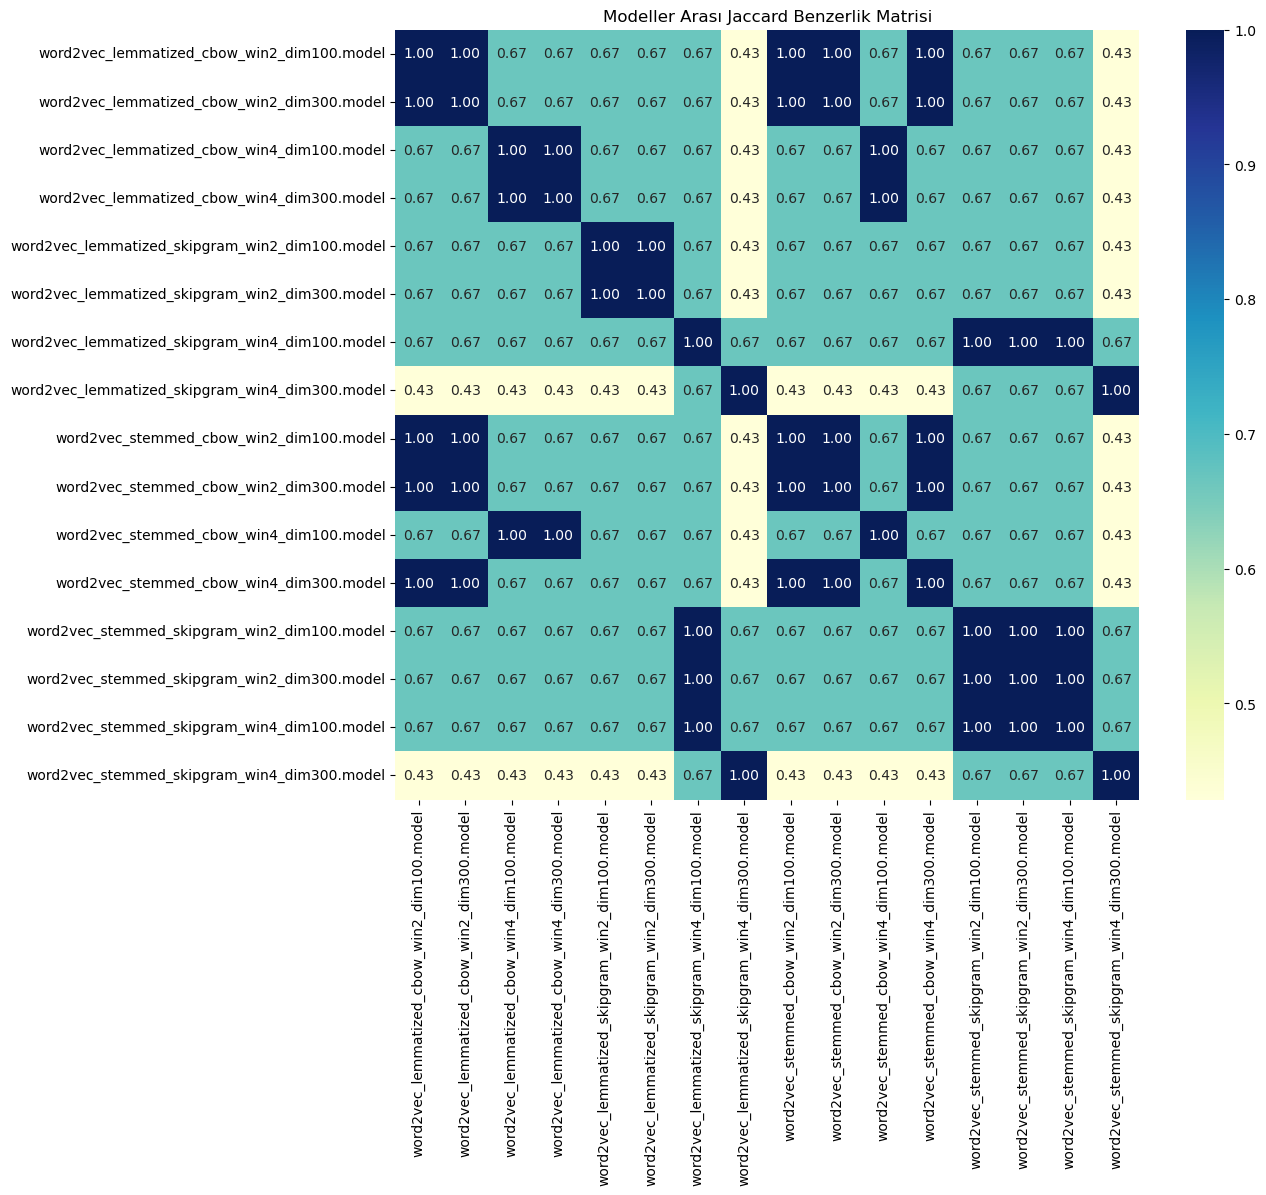

In [16]:
# 'results' sözlüğünün zaten 2. adımdan bellekte olduğunu varsayıyorum.
# Eğer değilse, 2. adımdaki 'results' kısmını yukarıda tekrar tanımladığından emin ol.

model_names = list(results.keys())
jaccard_matrix = pd.DataFrame(index=model_names, columns=model_names)

for m1 in model_names:
    for m2 in model_names:
        # Jaccard = (Kesişim / Birleşim)
        set1 = results[m1]
        set2 = results[m2]
        intersection = len(set1.intersection(set2))
        union = len(set1.union(set2))
        jaccard_matrix.loc[m1, m2] = intersection / union

# Matrisi sayısal formata çevir (heatmap için gerekli)
jaccard_matrix = jaccard_matrix.astype(float)

# Matrisi göster
print(jaccard_matrix)

# Görselleştirmek için (İsteğe bağlı - Heatmap)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
sns.heatmap(jaccard_matrix, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Modeller Arası Jaccard Benzerlik Matrisi")
plt.show()